In [1]:
from mylib.statistic_test import *
from zfish._io import import16chFlt
from zfish.local_path import *
import os

import numpy as np
import matplotlib.pyplot as plt
from zfish.utils import *

code_id = "5007 - Spatial Preference"
loc = os.path.join(figpath, code_id)
os.makedirs(loc, exist_ok=True)

landmark_pos = [
    (0, 1/18), # Starting Point box
    (1/9, 2/9), # Leaves
    (5/18, 7/18), # Stars
    (4/9, 5/9), # Polygons
    (11/18, 13/18), # Triangles
    (14/18, 15/18), # Gravel
    (16/18, 17/18) # Teeth of Predators
]

d:\Software\Anaconda3\envs\maze\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20260404

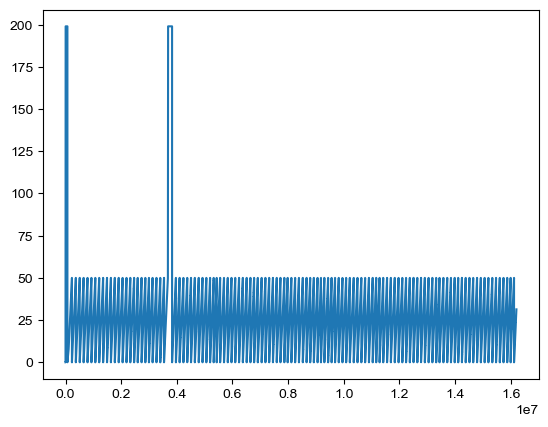

In [17]:
path = r"D:\EnData\Light-sheet\10158\S2\res.16chFlt"
res = import16chFlt(path)
plt.plot(res['behav_pos_y'])
res['Paradigm'][0]

In [2]:
def process(res: SwimDataDict):
    init_mask = filt_init_mask(res['behav_pos_y'], res['behav_time'])
    for k in res.keys():
        res[k] = res[k][init_mask]
        
    # Smooth both channel:
    for k in ['fltCh0', 'fltCh1']:
        res[k] = np.convolve(res[k], np.ones(600)/600, mode='same')
    
    # Compute speed:
    x = res['behav_pos_y'] + 50 * res['n_trials']
    t = res['behav_time']
    dx = np.diff(x)
    dt = np.diff(t)
    
    idx = np.append([0], np.where(dx/dt >= 0)[0])  # Threshold for movement, can be adjusted
    for k in res.keys():
        res[k] = res[k][idx]    
    
    dx = dx[idx[1:]]  # Adjust dx to match the length of idx
    dt = dt[idx[1:]]  # Adjust dt to match the length of idx
    
    speed = np.convolve(dx/dt, np.ones(600)/600, mode='same')
    speed = np.concatenate([[0], speed])  # Pad the first element to match the length of other arrays
    res['smooth_speed'] = speed
    

    
    # Downsample fro 6kHz to 30Hz:
    for k in res.keys():
        res[k] = res[k][::200]    
    
    for k in res.keys():
        res[k] = res[k][10:-10]
        
    return res

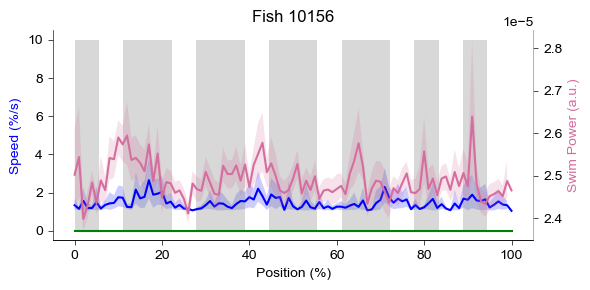

In [3]:
# file_dir = r"D:\EnData\Light-sheet\spatial preference vr1\10153\S2\res.16chFlt"
file_dir = r"D:\EnData\Light-sheet\10156\S2\res.16chFlt"
fish_id = 10156
res: SwimDataDict = import16chFlt(file_dir)
res = process(res)
res['behav_pos_y'] = (res['behav_pos_y'] // 0.5).astype(np.int32)
res['behav_pos_y_rand'] = np.roll(res['behav_pos_y'], np.random.randint(12000, len(res['behav_pos_y'])))

idx = np.where(res['n_trials'] <= 10)[0]
for k in res.keys():
    res[k] = res[k][idx]

if fish_id == 10141:
    res['mean_fltCh'] = res['fltCh1']
else:
    res['mean_fltCh'] = (res['fltCh0'] + res['fltCh1']) / 2
fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='behav_pos_y', 
    y='smooth_speed',
    data=res,
    ax=ax,
    color="blue",
    err_kws={'edgecolor': None}
)
ax.spines['left'].set_color('blue')
sns.lineplot(
    x='behav_pos_y', 
    y='opto_states',
    data=res,
    color='green',
    ax=ax,
    err_kws={'edgecolor': None}
)
axt = Clear_Axes(ax.twinx(), close_spines=['top', 'left'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='behav_pos_y', 
    y='mean_fltCh',
    data=res,
    color=ChannelColors[0],
    ax=axt,
    err_kws={'edgecolor': None}
)

axt.spines['right'].set_color(ChannelColors[0])
axt.set_ylabel("Swim Power (a.u.)", color=ChannelColors[0])
for (start, end) in landmark_pos:
    ax.fill_betweenx([0, 10], start*100, end*100, color='gray', alpha=0.3, edgecolor=None)
ax.set_xlabel('Position (%)')
ax.set_ylabel('Speed (%/s)', color='blue')
ax.set_title(f"Fish {fish_id}")
plt.tight_layout()
plt.savefig(os.path.join(loc, f"{fish_id} [first 10 trials].svg"), dpi=300)
plt.show()

# Upload Trace

In [2]:
path = r"D:\EnData\Light-sheet\10156"

with open(os.path.join(path, "trace.pkl"), 'rb') as f:
    trace = pickle.load(f)

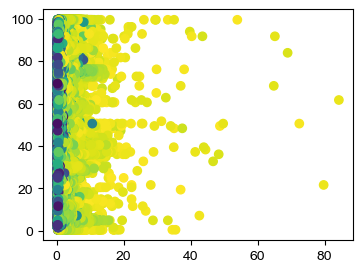

        D:\EnData\Light-sheet\10158\S2\RateMap is already existed!
66750
10056 9194 (9216, 10080) 2016 1152


In [2]:
def radar_visualization(
    x, y, 
    snr, 
    n_bin: int = 100, 
    cell_idx:np.ndarray = None, 
    meanImg=None,
    lenX:int=0,
    lenY:int=0,
    rois=None,
    fps: float = 2,
    map_id: np.ndarray = None
):
    theta = x / n_bin  * 2 * np.pi
    radial = y

    if map_id is None:
        map_id = np.ones_like(x, np.int64)
    else:
        assert map_id.shape[0] == x.shape[0], "map_id should have the same length as x"
    
    color_palette = sns.color_palette("Set2", n_colors=np.unique(map_id).shape[0])
    
    # Compute CI per bin
    def compute_CI(x, y, map_id = None):
        if map_id is None:
            map_id = np.ones_like(x, np.int64)
        else:
            assert map_id.shape[0] == x.shape[0], "map_id should have the same length as x"
            
        n_maps = np.unique(map_id).shape[0]
        ms = np.unique(map_id)
            
        top_boundary = np.zeros((n_bin, n_maps))
        low_boundary = np.zeros((n_bin, n_maps))
        means = np.zeros((n_bin, n_maps))
        for m in range(n_maps):
            for i in range(n_bin):
                bin_values = y[(x == i)&(map_id == ms[m])]
                if len(bin_values) > 0:
                    mean = np.nanmean(bin_values)
                    means[i, m] = mean
                    sem = np.nanstd(bin_values) / np.sqrt(len(bin_values))
                    top_boundary[i, m] = mean + sem
                    low_boundary[i, m] = mean - sem
                else:
                    top_boundary[i, m] = np.nan
                    low_boundary[i, m] = np.nan

        x = np.arange(n_bin)/n_bin * 2 * np.pi
        x = np.tile(x[:, np.newaxis], (1, n_maps))  # Shape: (n_bin, n_maps)
        y = means
        return x, y, low_boundary, top_boundary
    
    fig = plt.figure(figsize=(9, 6))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 3])

    ax1 = fig.add_subplot(gs[0, 0])                    # row 1, col 1, normal 2D
    ax2 = fig.add_subplot(gs[0, 1])                    # row 1, col 2, normal 2D
    ax4 = fig.add_subplot(gs[1, 0])                    # row 2, col 1, normal 2D
    ax3 = fig.add_subplot(gs[1, 1], projection='polar')  # row 2, col 2, radar/polar
    for i in tqdm(cell_idx):
        ax1 = Clear_Axes(ax1, close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        ax1.plot(np.arange(len(y[i]))/fps, y[i], color='k', linewidth=0.3)
        ax1.set_title(f"Cell {i} (SNR: {snr[i]:.2f})")
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Raw dF/F')
        
        # Tuning Curve ============================
        ax2 = Clear_Axes(ax2, close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    
        sns.lineplot(x=x/n_bin*100, y=y[i], hue=map_id, ax=ax2, err_kws={'edgecolor': None}, linewidth=0.5, palette=color_palette)
        ylims = ax2.get_ylim()
        for (start, end) in landmark_pos:
            ax2.fill_betweenx(ylims, start*100, end*100, color=ChannelColors[0], alpha=0.1, edgecolor=None)      
        ax2.set_xlabel('Position (%)')  
        ax2.set_ylabel('Raw dF/F')
        ax2.set_xticks(np.linspace(0, 100, 6))
        
        ax4 = Clear_Axes(ax4)
        iplane = rois[i, 2]
    
        y_total, x_total = meanImg.shape
        x_nplane, y_nplane = int(x_total / lenX), int(y_total / lenY)
        xp, yp = iplane % x_nplane, iplane // x_nplane
        x_roi = int(rois[i, 0] - xp*lenX)
        y_roi = int(rois[i, 1] - yp*lenY)
        
        ax4.imshow(meanImg[yp*lenY:(yp+1)*lenY, xp*lenX:(xp+1)*lenX], cmap='gray')
        ax4.scatter(x_roi, y_roi, color='red', s=10, edgecolor=None)
        ax4.set_title(f"Plane {iplane}")
        
        # Radar plot ============================
        x0, y0, low_boundary, top_boundary = compute_CI(x, y[i], map_id)
        x0 = np.concatenate((x0, [x0[0]]), axis=0)  # Close the loop
        y0 = np.concatenate((y0, [y0[0]]), axis=0)  # Close the loop
        low_boundary = np.concatenate((low_boundary, [low_boundary[0]]), axis=0)  # Close the loop
        top_boundary = np.concatenate((top_boundary, [top_boundary[0]]), axis=0)  # Close the loop
        
        
        ax3.plot(np.arange(n_bin)/n_bin * 2 * np.pi, np.zeros(n_bin), color='red', linewidth=0.5)
        # Set the 4 background angular lines
        ax3.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
        ax3.set_xticklabels(["0%", "25%", "50%", "75%"])
        
        d_min, d_max = np.min(low_boundary), np.max(top_boundary)
        for (start, end) in landmark_pos:
            ax3.fill_betweenx([d_min, d_max], start*2*np.pi, end*2*np.pi, color=ChannelColors[0], alpha=0.1, edgecolor=None)
        
        n_maps = x0.shape[1]
        for m in range(n_maps):
            ax3.plot(x0[:, m], y0[:, m], linewidth=0.5, label = f"Map {m}")
            ax3.fill_between(x=x0[:, m], y1=low_boundary[:, m], y2=top_boundary[:, m], color=color_palette[m], alpha=0.3, edgecolor=None)
            
        plt.legend(loc='upper right', edgecolor=None, facecolor=None, fontsize=6)
        plt.savefig(os.path.join(save_dir, f"Cell {i}.png"), dpi=300)
        ax1.clear()
        ax2.clear()
        ax3.clear()
        ax4.clear()
    plt.show()

plt.figure(figsize=(4, 3))
plt.scatter(
    x=trace['tuning_params']['amplitude'], 
    y=trace['tuning_params']['center'], 
    c=trace['snr']
)
plt.show()

save_dir = os.path.join(path, "RateMap")
mkdir(save_dir)
x = trace['spike_nodes'][200:]
y = trace['RawTraces'][:, 200:]
idx = np.where(trace['tuning_params']['amplitude'] > 1)[0]
print(idx.shape[0])

n_bins = 100
"""
radar_visualization(
    x, y, 
    snr=trace['snr'], 
    n_bin=trace['rate_map_all'].shape[1], 
    cell_idx=idx[5850:], 
    meanImg=trace['meanImg'],
    lenX=trace['lenX'],
    lenY=trace['lenY'],
    rois=trace['roi_coord'],
    fps=trace['fs']
)
"""
print(np.max(trace['roi_coord'][:, 0]), np.max(trace['roi_coord'][:, 1]), trace['meanImg'].shape, trace['lenX'], trace['lenY'])

# Correlation Analysis

In [3]:
idx = np.where(trace['snr'] >= 0.6)[0]
corr = np.corrcoef(trace['rate_map_all'][idx, :, 0])

Fitted parameters: [0.92003353 0.10850158 0.28697837 0.86208875 0.59453218 0.15542763]


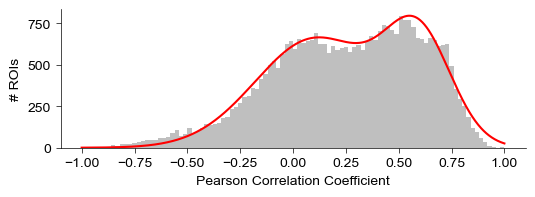

(1655,)


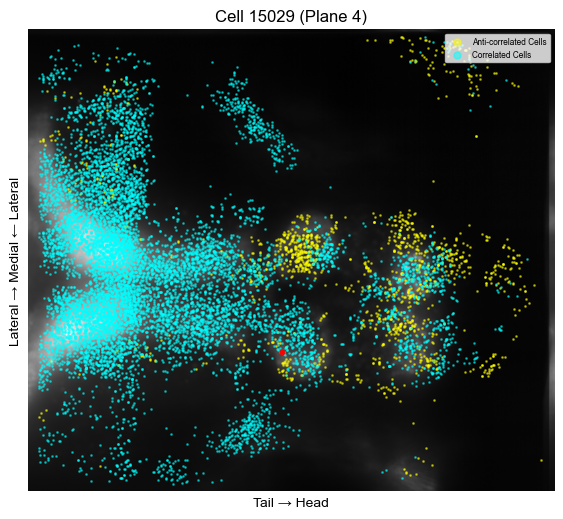

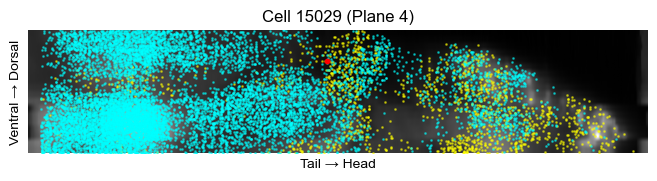

In [4]:
cell_id = 15029

pos = np.where(idx==cell_id)[0][0] 
# 15029 and 15120 are anti-correlated
# 56036 is a great control
import numpy as np
from scipy.optimize import curve_fit

def two_gaussians(x, a1, mu1, sigma1, a2, mu2, sigma2):
    g1 = a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    g2 = a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    return g1 + g2

p0 = [0.5, 0, 0.5, 0.5, 0.5, 0.5]
dist = np.histogram(corr[pos, :], bins=100, range=(-1, 1), density=True)[0]
bins = np.linspace(-1, 1, 101)
bins = (bins[:-1] + bins[1:]) / 2
popt, _ = curve_fit(two_gaussians, bins, dist, p0=p0)
x_fit = np.linspace(-1, 1, 1000)
y_fit = two_gaussians(x_fit, *popt)
print("Fitted parameters:", popt)

fig = plt.figure(figsize=(6, 1.8))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
a = ax.hist(corr[pos, :], bins=100, range=(-1, 1), color='gray',alpha=0.5)[0]
ax.plot(x_fit, y_fit*a.max()/y_fit.max(), color='red')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('# ROIs')
plt.show()
print(np.where(corr[pos, :] > 0.75)[0].shape)

# Spatial map
meanImg = []
lenX, lenY = trace['lenX'], trace['lenY']
nx, ny = int(trace['meanImg'].shape[1] / lenX), int(trace['meanImg'].shape[0] / lenY)
nps = trace['nplanes']
for i in range(nps):
    xplane, yplane = i % nx, i // nx
    meanImg.append(trace['meanImg'][yplane*lenY:(yplane+1)*lenY, xplane*lenX:(xplane+1)*lenX])
meanImg = np.stack(meanImg, axis=2)

rois = trace['roi_coord'][cell_id, :]
plt.figure(figsize=(8,6))
ax = Clear_Axes(plt.axes())
ax.imshow(meanImg[:,:,rois[2]], cmap='gray', aspect='equal'),
ax.set_title(f"Cell {cell_id} (Plane {rois[2]})")
anticorr_cells = np.where(corr[pos, :] < -0.4)[0]
corr_cells = np.where(corr[pos, :] > 0.5)[0]
ax.scatter(
    trace['roi_coord'][idx[anticorr_cells], 0] - (trace['roi_coord'][idx[anticorr_cells], 2] % nx)*lenX, 
    trace['roi_coord'][idx[anticorr_cells], 1] - (trace['roi_coord'][idx[anticorr_cells], 2] // nx)*lenY, 
    color='yellow', s=1, edgecolor=None, label='Anti-correlated Cells', alpha=0.5
)
ax.scatter(
    trace['roi_coord'][idx[corr_cells], 0] - (trace['roi_coord'][idx[corr_cells], 2] % nx)*lenX, 
    trace['roi_coord'][idx[corr_cells], 1] - (trace['roi_coord'][idx[corr_cells], 2] // nx)*lenY, 
    color='cyan', s=1, edgecolor=None, label='Correlated Cells',alpha=0.5
)
xplane, yplane = rois[2] % nx, rois[2] // nx
ax.scatter(rois[0]-xplane*lenX, rois[1]-yplane*lenY, color='red', s=10, edgecolor=None)
ax.legend(loc='upper right', markerscale=5, fontsize=6)
ax.set_xlabel('Tail → Head')
ax.set_ylabel('Lateral → Medial ← Lateral')
plt.show()

plt.figure(figsize=(8, 1.6))
ax = Clear_Axes(plt.axes())
ax.imshow(meanImg[rois[0]].T, cmap='gray', aspect='auto'),
ax.set_title(f"Cell {cell_id} (Plane {rois[2]})")
anticorr_cells = np.where(corr[pos, :] < -0.4)[0]
corr_cells = np.where(corr[pos, :] > 0.5)[0]
ax.scatter(
    trace['roi_coord'][idx[anticorr_cells], 0] - (trace['roi_coord'][idx[anticorr_cells], 2] % nx)*lenX, 
    trace['roi_coord'][idx[anticorr_cells], 2] + np.random.rand(len(anticorr_cells)) - 0.5, 
    color='yellow', s=1, edgecolor=None, label='Anti-correlated Cells', alpha=0.5
)
ax.scatter(
    trace['roi_coord'][idx[corr_cells], 0] - (trace['roi_coord'][idx[corr_cells], 2] % nx)*lenX, 
    trace['roi_coord'][idx[corr_cells], 2] + np.random.rand(len(corr_cells)) - 0.5, 
    color='cyan', s=1, edgecolor=None, label='Correlated Cells',alpha=0.5
)
ax.scatter(rois[0]-xplane*lenX, rois[2], color='red', s=10, edgecolor=None)
ax.set_xlabel('Tail → Head')
ax.set_ylabel('Ventral → Dorsal')
plt.show()

# Spatial Map Clustering

In [ ]:

def compute_CI(x, y, map_id = None, n_bin=100):
    if map_id is None:
        map_id = np.ones_like(x, np.int64)
    else:
        assert map_id.shape[0] == x.shape[0], "map_id should have the same length as x"
            
    n_maps = np.unique(map_id).shape[0]
    ms = np.unique(map_id)
            
    top_boundary = np.zeros((n_bin, n_maps))
    low_boundary = np.zeros((n_bin, n_maps))
    means = np.zeros((n_bin, n_maps))
    for m in range(n_maps):
        for i in range(n_bin):
            bin_values = y[(x == i)&(map_id == ms[m])]
            if len(bin_values) > 0:
                mean = np.nanmean(bin_values)
                means[i, m] = mean
                sem = np.nanstd(bin_values) / np.sqrt(len(bin_values))
                top_boundary[i, m] = mean + sem
                low_boundary[i, m] = mean - sem
            else:
                top_boundary[i, m] = np.nan
                low_boundary[i, m] = np.nan

    x = np.arange(n_bin)/n_bin * 2 * np.pi
    x = np.tile(x[:, np.newaxis], (1, n_maps))  # Shape: (n_bin, n_maps)
    y = means
    return x, y, low_boundary, top_boundary

save_dir = os.path.join(path, "SpatialMapClustering")
mkdir(save_dir)
x = trace['spike_nodes'][100:]
y = trace['RawTraces'][:, 100:]
map_id = trace['ms_map'][100:]

_, y_map, l, t = compute_CI(x, y, map_id=map_id, n_bin=trace['rate_map_all'].shape[1])
sem_map = t - l
    
total_maps = y_map#np.concatenate([y_map, sem_map], axis=1)
raw_maps = total_maps.copy()
#total_maps = (total_maps-np.min(y_map, axis=1, keepdims=True)) / (np.max(y_map, axis=1, keepdims=True) - np.min(y_map, axis=1, keepdims=True)) # Normalize by max response for better visualization

        D:\EnData\Light-sheet\10156\SpatialMapClustering is already existed!


100%|██████████| 100/100 [00:22<00:00,  4.42it/s]


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] (33449,)
Clustering down: 
  [  75 1358  222  192 7928  219  523  701   47  485 6840  182  645  528
   26  142  624  579    1  429 1514 1165    1  244    5  729  519    2
    1 3226  263  214  411    1  381 1940  907  110   69    1]


100%|██████████| 40/40 [00:00<00:00, 50.25it/s]


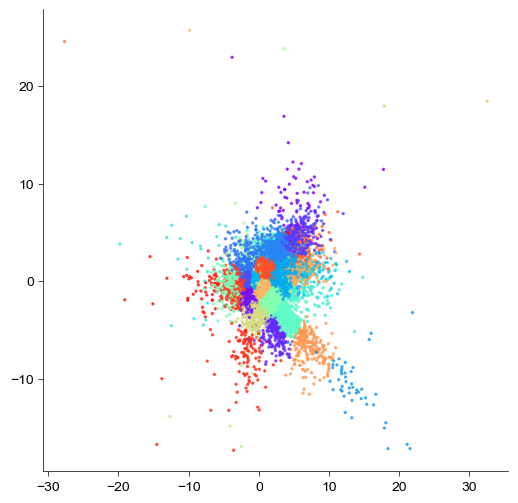

In [6]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA   

qualified_cells = np.where(trace['p_values'] < 0.005)[0]

kmeans = KMeans(n_clusters=40, random_state=0)
kmeans.fit(total_maps[qualified_cells])
clusters = kmeans.labels_.astype(np.int32)
clusters -= np.min(clusters)  # Shift cluster labels to start from 0
print(np.unique(clusters), clusters.shape)
color = sns.color_palette("rainbow", np.max(clusters)+1)
print(f"Clustering down: \n  {np.histogram(clusters, bins=np.arange(-0.5, np.max(clusters)+1.5, 1))[0]}")

# Compute mean tuning curve for each cluster
centroid_map = np.zeros((np.max(clusters)+1, y_map.shape[1]))
for i in tqdm(range(np.max(clusters)+1)):
    centroid_map[i] = np.mean(y_map[qualified_cells][clusters == i], axis=0)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(total_maps[qualified_cells])

plt.figure(figsize=(6, 6))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.scatter(
    pca_result[:, 0], 
    pca_result[:, 1], 
    c=clusters,
    cmap='rainbow', 
    alpha=0.7, 
    s=2,
    edgecolors=None
)
plt.show()

In [48]:

from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d

rois = cp.deepcopy(trace['roi_coord'])[qualified_cells, :]

def calc_density(
    rois: np.ndarray,
    stype: str = 'xy',
    nx = 100,
    ny = 100,
    sigma = 5
):
    if stype == 'xy':
        x, y = rois[:, 0], rois[:, 1]
    elif stype == 'xz':
        x, y = rois[:, 0], rois[:, 2]
    elif stype == 'yz':
        x, y = rois[:, 1], rois[:, 2]
    else:
        raise ValueError("stype must be one of 'xy', 'xz', 'yz'")
    
    
    # smooth the heatmap
    
    if stype == 'xy':
        heatmap, xedges, yedges = np.histogram2d(x, y, bins=[nx, ny], range=[[0-0.5, nx-0.5], [0-0.5, ny-0.5]])
        heatmap = gaussian_filter(heatmap, sigma=sigma)
    else:
        heatmap, xedges, yedges = np.histogram2d(x, y, bins=[200, ny], range=[[0-0.5, nx-0.5], [0-0.5, ny-0.5]])
        interp_heatmap = np.zeros((nx, heatmap.shape[1]))
        # interpolate the heatmap to nx, ny
        for i in range(heatmap.shape[1]):
            heatmap[:, i] = gaussian_filter(heatmap[:, i], sigma=sigma)
            
            x_old = np.linspace(0, 1, heatmap.shape[0])
            x_new = np.linspace(0, 1, nx)
            f = interp1d(x_old, heatmap[:, i], axis=0, kind='linear')
            interp_heatmap[:, i] = f(x_new)
        heatmap = interp_heatmap

    return heatmap

def visualize_cluster_3d(
    rois: np.ndarray, 
    meanImg: np.ndarray,
    color: str = ChannelColors[0],
    lenX: int = 512,
    lenY: int = 512,
    ax = None
):
    # 3d scatter plot of ROIs colored by cluster
    rois[:, 0] = rois[:, 0] % lenX + np.random.rand(rois.shape[0]) - 0.5
    rois[:, 1] = rois[:, 1] % lenY + np.random.rand(rois.shape[0]) - 0.5
    scatter = ax.scatter(
        rois[:, 0]+np.random.rand(rois.shape[0])-0.5, 
        rois[:, 1]+np.random.rand(rois.shape[0])-0.5,  
        rois[:, 2]+np.random.rand(rois.shape[0])-0.5,
        c=[color] * rois.shape[0],
        alpha=1, 
        s=1,
        edgecolors=None
    )
    
    # project 2d planes onto the bottom
    #meanImg = meanImg[::4, :, :] + meanImg[1::4, :, :] + meanImg[2::4, :, :] + meanImg[3::4, :, :]
    #meanImg = meanImg[:, ::4, :] + meanImg[:, 1::4, :] + meanImg[:, 2::4, :] + meanImg[:, 3::4, :]
    ny, nx, nz = meanImg.shape
    print(ny, nx, nz)
    
    z_plane = nz
    x_plane = -10
    y_plane = ny+10
    
    X_xy, Y_xy = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
    img_xy_n = np.mean(meanImg, axis=2)
    img_xy_n = np.clip(img_xy_n, 0, np.percentile(img_xy_n, 90))
    Z_xy = np.zeros_like(X_xy).astype(np.float32)+z_plane

    density_xy = calc_density(rois, stype='xy', nx=nx, ny=ny)
    Z_xy[density_xy > 1e-5] = np.nan
    ax.contourf(
        X_xy, Y_xy, density_xy, 
        zdir='z', offset=z_plane, cmap=sns.dark_palette("#79C", as_cmap=True)
    )
    ax.plot_surface(
        X_xy, Y_xy, Z_xy,
        facecolors=sns.color_palette("gray", as_cmap=True)(img_xy_n.T / np.max(img_xy_n)),
    ) 
    
    img_xz_n = np.mean(meanImg, axis=0)
    img_xz_n = np.clip(img_xz_n, 0, np.percentile(img_xz_n, 90))  
    img_xz_interp = np.zeros((nx, 1000))  
    heatmap_xz = calc_density(rois, stype='xz', nx=nx, ny=nz, sigma=1)
    
    heatmap_xz_interp = np.zeros((nx, 1000))
    for i in range(img_xz_n.shape[0]):
        x_old = np.linspace(0, 1, img_xz_n.shape[1])
        x_new = np.linspace(0, 1, 1000)
        f = interp1d(x_old, img_xz_n[i, :], axis=0, kind='linear')
        img_xz_interp[i, :] = f(x_new)
        f = interp1d(x_old, heatmap_xz[i, :], axis=0, kind='linear')
        heatmap_xz_interp[i, :] = f(x_new)
        
    X_xz, Z_xz = np.meshgrid(np.arange(nx), np.linspace(0, nz-1, 1000), indexing='ij')
    Y_xz = np.zeros_like(X_xz).astype(np.float32)+y_plane
    Y_xz[heatmap_xz_interp > 5e-3] = np.nan
    heatmap_xz_interp[heatmap_xz_interp <= 5e-3] = np.nan
    ax.contourf(
        X_xz, heatmap_xz_interp, Z_xz,
        zdir='y', offset=y_plane, cmap=sns.dark_palette("#79C", as_cmap=True)
    )
    ax.plot_surface(
        X_xz, Y_xz, Z_xz,
        facecolors=sns.color_palette("gray", as_cmap=True)(img_xz_interp / np.max(img_xz_n)),
    )
    
    
    img_yz_n = np.mean(meanImg, axis=1)
    img_yz_n = np.clip(img_yz_n, 0, np.percentile(img_yz_n, 90))
    img_yz_interp = np.zeros((ny, 1000))    
    heatmap_yz = calc_density(rois, stype='yz', nx=ny, ny=nz, sigma=1)
    heatmap_yz_interp = np.zeros((ny, 1000))
    for i in range(img_yz_n.shape[0]):
        x_old = np.linspace(0, 1, img_yz_n.shape[1])
        x_new = np.linspace(0, 1, 1000)
        f = interp1d(x_old, img_yz_n[i, :], axis=0, kind='linear')
        img_yz_interp[i, :] = f(x_new)
        f = interp1d(x_old, heatmap_yz[i, :], axis=0, kind='linear')
        heatmap_yz_interp[i, :] = f(x_new)
        
    Y_yz, Z_yz = np.meshgrid(np.arange(ny), np.linspace(0, nz-1, 1000), indexing='ij')
    X_yz = np.zeros_like(Y_yz).astype(np.float32)+x_plane
    X_yz[heatmap_yz_interp > 5e-3] = np.nan
    heatmap_yz_interp[heatmap_yz_interp <= 5e-3] = np.nan
    ax.contourf(
        heatmap_yz_interp, Y_yz, Z_yz,
        zdir='x', offset=x_plane, cmap=sns.dark_palette("#79C", as_cmap=True)
    )
    ax.plot_surface(
        X_yz, Y_yz, Z_yz,
        facecolors=sns.color_palette("gray", as_cmap=True)(img_yz_interp / np.max(img_yz_n)),
    )
    
    ax.set_xlim(x_plane, lenX)
    ax.set_ylim(0, y_plane)
    ax.set_zlim(0, z_plane)
    ax.set_xlabel("Caudal → Rostro")
    ax.set_ylabel("Lateral → Medial ← Lateral")
    ax.set_zlabel("Ventral → Dorsal")
    ax.invert_zaxis()
    ax.view_init(elev=30, azim=-30)

def visualize_cluster(
    rois: np.ndarray, 
    meanImg: np.ndarray,
    total_maps: np.ndarray,
    color: str = ChannelColors[0],
    n_bin: int = 100,
    lenX: int = 512,
    lenY: int = 512,
):
    # Compute CI per bin
    def compute_CI(x, y):
        top_boundary = np.zeros(n_bin)
        low_boundary = np.zeros(n_bin)
        means = np.zeros(n_bin)
        for i in range(n_bin):
            bin_values = y[x == i]
            if len(bin_values) > 0:
                mean = np.nanmean(bin_values)
                means[i] = mean
                sem = np.nanstd(bin_values) / np.sqrt(len(bin_values))
                top_boundary[i] = mean + sem
                low_boundary[i] = mean - sem
            else:
                top_boundary[i] = np.nan
                low_boundary[i] = np.nan

        x = np.arange(n_bin)/n_bin * 2 * np.pi
        y = means
        return x, y, low_boundary, top_boundary
    
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(4,2, figure=fig, width_ratios=[2, 1])
    ax2 = fig.add_subplot(gs[:2, 1])                    # row 1, col 2, normal 2D
    Clear_Axes(ax2, close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    #ax1 = fig.add_subplot(gs[:, 0], projection='3d')  # row 2, col 1, 3D scatter
    ax10 = fig.add_subplot(gs[0, 0])                    # row 1, col 1, normal 2D
    ax11 = fig.add_subplot(gs[1:, 0])                    # row 2, col 1, normal 2D
    ax4 = fig.add_subplot(gs[2:, 1], projection='polar')  # row 2, col 2, radar/polar
    
    x = np.linspace(0, 100, total_maps.shape[1]+1)
    x = (x[:-1] + x[1:]) / 2  # Bin centers
    for i in range(total_maps.shape[0]):
        ax2.plot(x, total_maps[i, :], color='gray', alpha=0.3)
    res = {
        'x': np.tile(x, (total_maps.shape[0], 1)).flatten(),
        'xbin': np.tile(np.arange(total_maps.shape[1]), (total_maps.shape[0], 1)).flatten(),
        'y': total_maps.flatten()
    }
    sns.lineplot(
        x='x', 
        y='y', 
        data=res, 
        ax=ax2, 
        color=color,
        errorbar='sd',
        linewidth=2,
        err_kws={'edgecolor': None}
    )
    ylims = ax2.get_ylim()
    for (start, end) in landmark_pos:
        ax2.fill_betweenx(ylims, start*100, end*100, color=ChannelColors[0], alpha=0.1, edgecolor=None)
    ax2.set_xlabel('Position (%)')
    ax2.set_ylabel('Raw dF/F (a.u.)')
    
    # Radar plot ============================
    x0, y0, low_boundary, top_boundary = compute_CI(res['xbin'], res['y'])
    x0 = np.append(x0, x0[0])  # Close the loop
    y0 = np.append(y0, y0[0])  # Close the loop
    low_boundary = np.append(low_boundary, low_boundary[0])  # Close the loop
    top_boundary = np.append(top_boundary, top_boundary[0])  # Close the loop
    n_bin = total_maps.shape[1]
    ax4.plot(np.arange(n_bin)/n_bin * 2 * np.pi, np.zeros(n_bin), color='red', linewidth=0.5)
    # Set the 4 background angular lines
    ax4.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    ax4.set_xticklabels(["0%", "25%", "50%", "75%"])
        
    d_min, d_max = np.min(low_boundary), np.max(top_boundary)
    for (start, end) in landmark_pos:
        ax4.fill_betweenx([d_min, d_max], start*2*np.pi, end*2*np.pi, color=ChannelColors[0], alpha=0.1, edgecolor=None)
    ax4.plot(x0, y0, linewidth=0.5)
    ax4.fill_between(x=x0, y1=low_boundary, y2=top_boundary, color=color, alpha=0.3, edgecolor=None)
    
    # 3D scatter plot of ROIs colored by cluster
    rois[:, 0] = rois[:, 0] % lenX + np.random.rand(rois.shape[0]) - 0.5
    rois[:, 1] = rois[:, 1] % lenY + np.random.rand(rois.shape[0]) - 0.5
    ax11 = Clear_Axes(ax11)
    meanImg_n = np.clip(np.mean(meanImg, axis=2), 0, np.percentile(meanImg.flatten(), 90))
    ax11.imshow(meanImg_n, cmap='gray', aspect='equal')
    ax11.scatter(
        rois[:, 0], 
        rois[:, 1],  
        color=color, s=1, edgecolors=None, alpha=0.5
    )
    ax11.set_xlabel("Caudal → Rostro")
    ax11.set_ylabel("Lateral → Medial ← Lateral")
    
    ax10 = Clear_Axes(ax10)
    iplane = rois[0, 2]
    ax10.imshow(np.mean(meanImg, axis=0).T, cmap='gray', aspect='auto')
    ax10.scatter(
        rois[:, 0], 
        rois[:, 2] + np.random.rand(rois.shape[0]) - 0.5,  
        color=color, s=1, edgecolors=None, alpha=0.5
    )
    ax10.set_xlabel("Caudal → Rostro")
    ax10.set_ylabel("Ventral → Dorsal")
    """
    visualize_cluster_3d(
        rois=rois, 
        meanImg=meanImg,
        color=color,
        lenX=lenX,
        lenY=lenY,
        ax=ax1
    )"""


meanImg = []
px, py = int(trace['meanImg'].shape[1] / trace['lenX']), int(trace['meanImg'].shape[0] / trace['lenY'])
for i in range(trace['nplanes']):
    nr, nc = i // px, i % px
    meanImg.append(trace['meanImg'][nr*trace['lenY']:(nr+1)*trace['lenY'], nc*trace['lenX']:(nc+1)*trace['lenX']])
meanImg = np.stack(meanImg, axis=2)

save_dir = os.path.join(path, "SpatialMapClustering")
mkdir(save_dir)


n_clusters_total = np.unique(clusters).shape[0]
clusters_color = sns.color_palette("rainbow", n_clusters_total)
for i in range(n_clusters_total):
    cluster_idx = np.where(clusters == i)[0]
    n_bin = int(total_maps.shape[1])
    visualize_cluster(
        rois=rois[cluster_idx, :], 
        meanImg=meanImg,
        total_maps=raw_maps[qualified_cells[cluster_idx], :],
        n_bin=n_bin,
        color=clusters_color[i],
        lenX=trace['lenX'],
        lenY=trace['lenY']
    )
    plt.suptitle(f"Cluster {i} (n={cluster_idx.shape[0]} ROIs)")
    plt.savefig(os.path.join(save_dir, f"Cluster {i}.png"), dpi=300)
    plt.close()
""""""

        D:\EnData\Light-sheet\10156\SpatialMapClustering is already existed!


''

[9]
[38 36 19 14 37  4  6  1 12 26 23 21  2 25 16  0 31 32  8  3  5 17  7 20
 11 30 13 34 15 29 35 10  9]


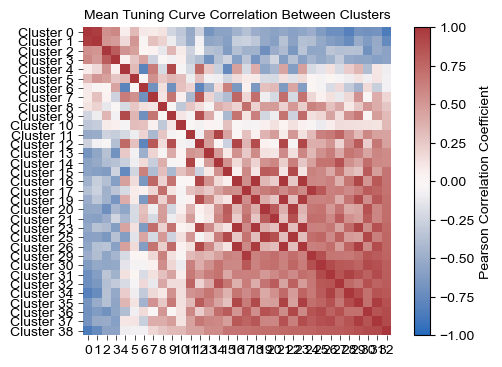

In [64]:
n_rois_per_cluster=np.zeros(np.max(clusters)+1).astype(np.int32)
for i in range(np.max(clusters)+1):
    n_rois_per_cluster[i] = np.sum(clusters == i)

keeps_idx = np.where(n_rois_per_cluster >= 20)[0]
print(np.where(keeps_idx == 9)[0])

corr = np.corrcoef(centroid_map[keeps_idx, :], rowvar=True)
argsort_idx = np.argsort(corr[:,9], axis=0)
print(keeps_idx[argsort_idx])
corr_resort = corr[argsort_idx][:, argsort_idx]
plt.figure(figsize=(6, 4))
ax = Clear_Axes(plt.axes(), ifxticks=True, ifyticks=True)
im = ax.imshow(
    corr_resort, cmap=sns.color_palette("vlag", as_cmap=True), vmin=-1, vmax=1
)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Pearson Correlation Coefficient')
ax.set_title("Mean Tuning Curve Correlation Between Clusters", fontsize=10)
ax.set_xticks(np.arange(len(keeps_idx)))
ax.set_yticks(np.arange(len(keeps_idx)), labels=[f"Cluster {i}" for i in keeps_idx])

(1250,)


<Axes: xlabel='X', ylabel='Y'>

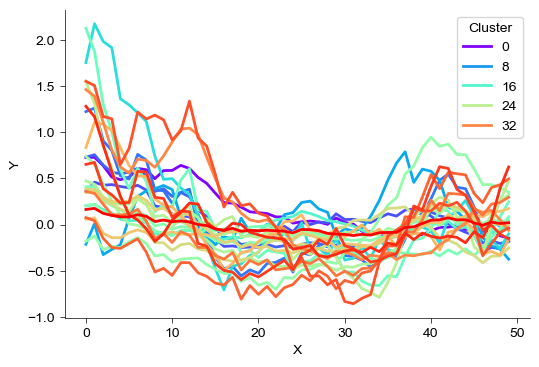

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
res = {
    "X": np.tile(np.arange(int(centroid_map.shape[1]/2)), (centroid_map.shape[0], 1)).flatten(),
    "Y": centroid_map[:, :int(centroid_map.shape[1]/2)].flatten(),
    "Cluster": np.tile(np.arange(centroid_map.shape[0])[:, np.newaxis], int(centroid_map.shape[1]/2)).flatten()
}
mean_map = centroid_map[:, :int(centroid_map.shape[1]/2)]

# MI and Results of Shuffle Test

In [1]:

# compute 
from sklearn.feature_selection import mutual_info_regression

MI = np.zeros(trace['RawTraces'][:, 200:].shape[0], np.float32)
for i in tqdm(range(trace['RawTraces'].shape[0])):
    MI[i] = mutual_info_regression(trace['RawTraces'][i, 200:].reshape(-1, 1), trace['spike_nodes'][200:])[0]

NameError: name 'np' is not defined

In [4]:
trace['mutual_info'] = MI
with open(os.path.join(path, "trace.pkl"), 'wb') as f:
    pickle.dump(trace, f)

# Two looped tracks

In [4]:
from mylib.statistic_test import *
from zfish._io import import16chFlt
from zfish.local_path import *
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from zfish.utils import *

code_id = "5007 - Spatial Preference"
loc = os.path.join(figpath, code_id, "2Tracks")
os.makedirs(loc, exist_ok=True)

landmark_pos = [
    (0, 1/18), # Starting Point box
    (2/18, 3/18), # Leaves
    (6/18, 7/18), # Stars
    (8/18, 9/18), # triangles
    (10/18, 11/18), # Polygons
    (14/18, 15/18), # Teeth of Predators
    (16/18, 17/18) # Gravel
]
landmark_bins = [
    np.arange(5),
    np.arange(10, 15),
    np.arange(30, 35),
    np.arange(40, 45),
    np.arange(50, 55),
    np.arange(70, 75),
    np.arange(80, 85)
]
convertor = np.array([0, 3, 5, 2, 1, 6, 4])
path = r"D:\EnData\Light-sheet\10158\S2"
with open(join(path, "trace.pkl"), 'rb') as f:
    trace = pickle.load(f)

# Mutual Information

<Axes: xlabel='MI', ylabel='Count'>

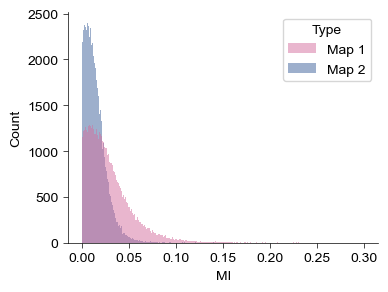

In [14]:
MI = trace['mutual_info']
res = {
    "Type": np.concatenate([
        np.repeat("Map 1", MI.shape[0]),
        np.repeat("Map 2", MI.shape[0])
    ]),
    "MI": np.concatenate([MI[:, 0], MI[:, 1]])
}
idx = np.where(res['MI'] > 0)[0]
for k in res.keys():
    res[k] = res[k][idx]

fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.histplot(
    data=res,
    x="MI",
    hue="Type",
    ax=ax,
    palette=ChannelColors,
    alpha=0.5, edgecolor=None,
    binrange=(0, 0.3)
)

# Scrutinize neural activity in telecephalon

In [2]:
meanImg, rois = get_meanImg(trace)
meanImg_xy = np.mean(meanImg, axis=2)

fore_brain_idx = np.where(
    (rois[:, 0] >= 1450) &
    (rois[:, 1] >= 200) &
    (rois[:, 1] < 650) &
    (trace['snr'] > 0.7)
)[0]
print(fore_brain_idx.shape[0])

4039


        D:\EnData\Light-sheet\10158\S2\RateMap\ForeBrain is made up successfully!
44
50419


100%|██████████| 4039/4039 [2:47:42<00:00,  2.49s/it]  


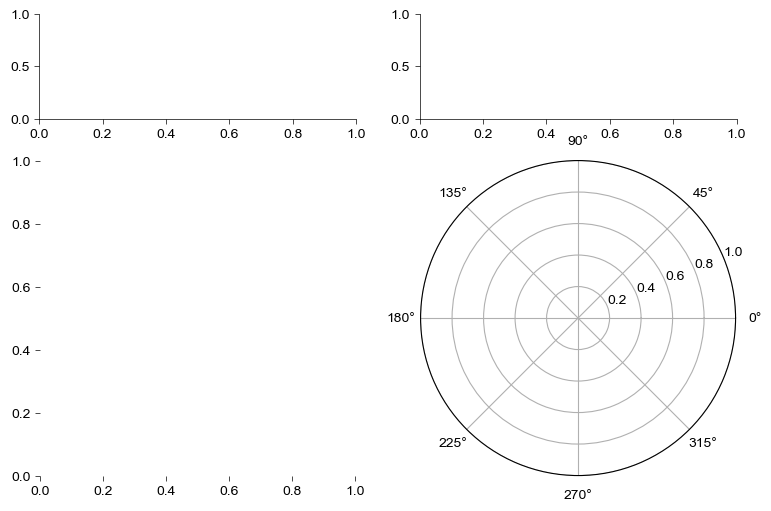

In [3]:
save_dir = os.path.join(path, "RateMap", "ForeBrain")
mkdir(save_dir)
x = trace['spike_nodes'][100:]
print(np.max(x))
y = trace['RawTraces'][:, 100:]
idx = np.where((trace['tuning_params']['amplitude'] > 1)&(trace['snr'] > 0.8))[0]
print(idx.shape[0])

n_bins = 45
idx_perm = np.random.permutation(idx)

def radar_visualization(
    x, y, 
    snr, 
    n_bin: int = 100, 
    cell_idx:np.ndarray = None, 
    meanImg=None,
    lenX:int=0,
    lenY:int=0,
    rois=None,
    fps: float = 2,
    map_id: np.ndarray = None
):
    theta = x / n_bin  * 2 * np.pi
    radial = y

    if map_id is None:
        map_id = np.ones_like(x, np.int64)
    else:
        assert map_id.shape[0] == x.shape[0], "map_id should have the same length as x"
    
    color_palette = sns.color_palette("Set2", n_colors=np.unique(map_id).shape[0])
    
    # Compute CI per bin
    def compute_CI(x, y, map_id = None):
        if map_id is None:
            map_id = np.ones_like(x, np.int64)
        else:
            assert map_id.shape[0] == x.shape[0], "map_id should have the same length as x"
            
        n_maps = np.unique(map_id).shape[0]
        ms = np.unique(map_id)
            
        top_boundary = np.zeros((n_bin, n_maps))
        low_boundary = np.zeros((n_bin, n_maps))
        means = np.zeros((n_bin, n_maps))
        for m in range(n_maps):
            for i in range(n_bin):
                bin_values = y[(x == i)&(map_id == ms[m])]
                if len(bin_values) > 0:
                    mean = np.nanmean(bin_values)
                    means[i, m] = mean
                    sem = np.nanstd(bin_values) / np.sqrt(len(bin_values))
                    top_boundary[i, m] = mean + sem
                    low_boundary[i, m] = mean - sem
                else:
                    top_boundary[i, m] = np.nan
                    low_boundary[i, m] = np.nan

        x = np.arange(n_bin)/n_bin * 2 * np.pi
        x = np.tile(x[:, np.newaxis], (1, n_maps))  # Shape: (n_bin, n_maps)
        y = means
        return x, y, low_boundary, top_boundary
    
    fig = plt.figure(figsize=(9, 6))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 3])

    ax1 = fig.add_subplot(gs[0, 0])                    # row 1, col 1, normal 2D
    ax2 = fig.add_subplot(gs[0, 1])                    # row 1, col 2, normal 2D
    ax4 = fig.add_subplot(gs[1, 0])                    # row 2, col 1, normal 2D
    ax3 = fig.add_subplot(gs[1, 1], projection='polar')  # row 2, col 2, radar/polar
    for i in tqdm(cell_idx):
        ax1 = Clear_Axes(ax1, close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        ax1.plot(np.arange(len(y[i]))/fps, y[i], color='k', linewidth=0.3)
        ax1.set_title(f"Cell {i} (SNR: {snr[i]:.2f})")
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Raw dF/F')
        
        # Tuning Curve ============================
        ax2 = Clear_Axes(ax2, close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    
        sns.lineplot(x=x/n_bin*100, y=y[i], hue=map_id, ax=ax2, err_kws={'edgecolor': None}, linewidth=0.5, palette=color_palette)
        ylims = ax2.get_ylim()
        for (start, end) in landmark_pos:
            ax2.fill_betweenx(ylims, start*100, end*100, color=ChannelColors[0], alpha=0.1, edgecolor=None)      
        ax2.set_xlabel('Position (%)')  
        ax2.set_ylabel('Raw dF/F')
        ax2.set_xticks(np.linspace(0, 100, 6))
        
        ax4 = Clear_Axes(ax4)
        iplane = rois[i, 2]
    
        y_total, x_total = meanImg.shape
        x_nplane, y_nplane = int(x_total / lenX), int(y_total / lenY)
        xp, yp = iplane % x_nplane, iplane // x_nplane
        x_roi = int(rois[i, 0] - xp*lenX)
        y_roi = int(rois[i, 1] - yp*lenY)
        
        ax4.imshow(meanImg[yp*lenY:(yp+1)*lenY, xp*lenX:(xp+1)*lenX], cmap='gray')
        ax4.scatter(x_roi, y_roi, color='red', s=10, edgecolor=None)
        ax4.set_title(f"Plane {iplane}")
        
        # Radar plot ============================
        x0, y0, low_boundary, top_boundary = compute_CI(x, y[i], map_id)
        x0 = np.concatenate((x0, [x0[0]]), axis=0)  # Close the loop
        y0 = np.concatenate((y0, [y0[0]]), axis=0)  # Close the loop
        low_boundary = np.concatenate((low_boundary, [low_boundary[0]]), axis=0)  # Close the loop
        top_boundary = np.concatenate((top_boundary, [top_boundary[0]]), axis=0)  # Close the loop
        
        
        ax3.plot(np.arange(n_bin)/n_bin * 2 * np.pi, np.zeros(n_bin), color='red', linewidth=0.5)
        # Set the 4 background angular lines
        ax3.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
        ax3.set_xticklabels(["0%", "25%", "50%", "75%"])
        
        d_min, d_max = np.min(low_boundary), np.max(top_boundary)
        for (start, end) in landmark_pos:
            ax3.fill_betweenx([d_min, d_max], start*2*np.pi, end*2*np.pi, color=ChannelColors[0], alpha=0.1, edgecolor=None)
        
        n_maps = x0.shape[1]
        for m in range(n_maps):
            ax3.plot(x0[:, m], y0[:, m], linewidth=0.5, label = f"Map {m}")
            ax3.fill_between(x=x0[:, m], y1=low_boundary[:, m], y2=top_boundary[:, m], color=color_palette[m], alpha=0.3, edgecolor=None)
            
        plt.legend(loc='upper right', edgecolor=None, facecolor=None, fontsize=6)
        plt.savefig(os.path.join(save_dir, f"Cell {i}.png"), dpi=300)
        ax1.clear()
        ax2.clear()
        ax3.clear()
        ax4.clear()
    plt.show()


radar_visualization(
    x, y, 
    snr=trace['snr'], 
    n_bin=trace['rate_map_all'].shape[1], 
    cell_idx=fore_brain_idx, 
    meanImg=trace['meanImg'],
    lenX=trace['lenX'],
    lenY=trace['lenY'],
    rois=trace['roi_coord'],
    fps=trace['fs'],
    map_id=trace['ms_map'][100:]
)